In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


1. importing the libraries numpy, pandas, matplotlib, seaborn, sklearn
2. loading the dataset
3. EDA(Exploratory Data Analysis) shape, info, describe, checking the missing values,
4. distribution of target variable, correlations
5. Splitting the features and target variable
6. Training the model using Linear Regression
7. Predicting the values using the model

In [2]:
# importing the dataset using pandas framework
# printing the first 5 values using .head() method
data_set = pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")
data_set.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# importing the required libraries

In [4]:
# the size of the dataset using .shape
# (m,n), m -> number of rows and n -> number of columns
data_set.shape

(1338, 7)

In [5]:
# knowing about the dataset using .info()
# Gives important values regarding the dataset
data_set.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Categorical values : 
    1. sex
    2. smoker
    3. region
Numerical values :
    1. age
    2. bmi
    3. charges

In [6]:
# Checking for missing values using .isnull()
data_set.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# Statistical measures of the dataset(only numerical columns) using .describe()
data_set.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 600x600 with 0 Axes>

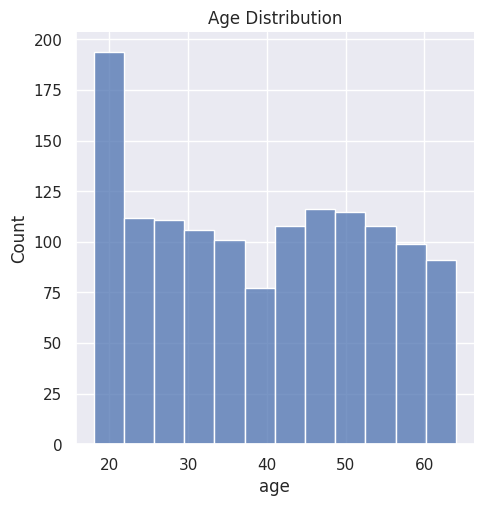

In [8]:
# Distribution of the age of the applicants
sns.set()
plt.figure(figsize=(6,6))
sns.displot(data_set["age"])
plt.title("Age Distribution")
plt.show()


<Figure size 600x600 with 0 Axes>

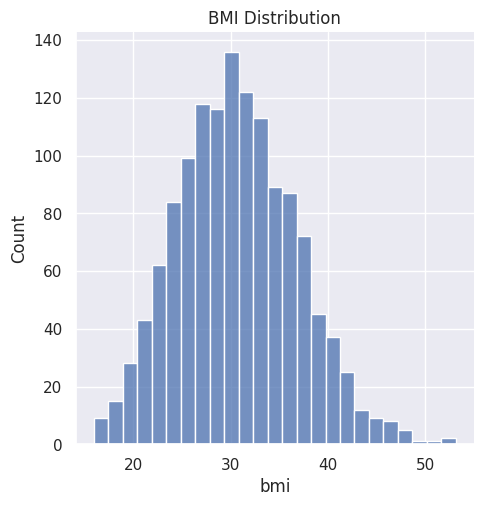

In [9]:
# Distribution of the bmi of applicants
plt.figure(figsize=(6,6))
sns.displot(x = 'bmi', data=data_set)
plt.title("BMI Distribution")
plt.show()

[](https://www.pacehospital.com/bmi-calculator-ranges-importance)

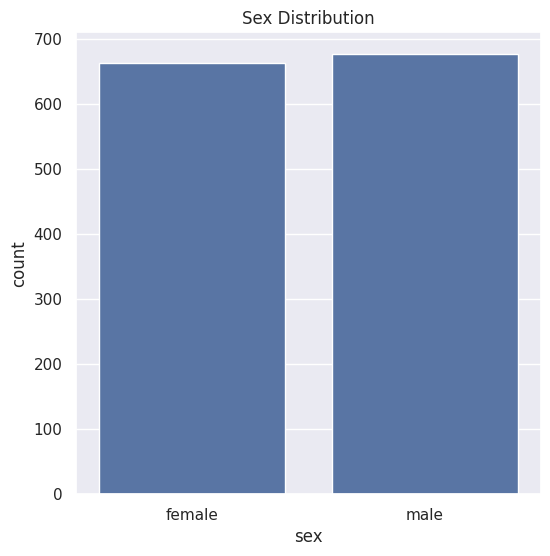

sex
male      676
female    662
Name: count, dtype: int64

In [10]:
# Distribution of the sex of the applicants
plt.figure(figsize=(6,6))
sns.countplot(x = 'sex', data=data_set)
plt.title("Sex Distribution")
plt.show()
data_set['sex'].value_counts()

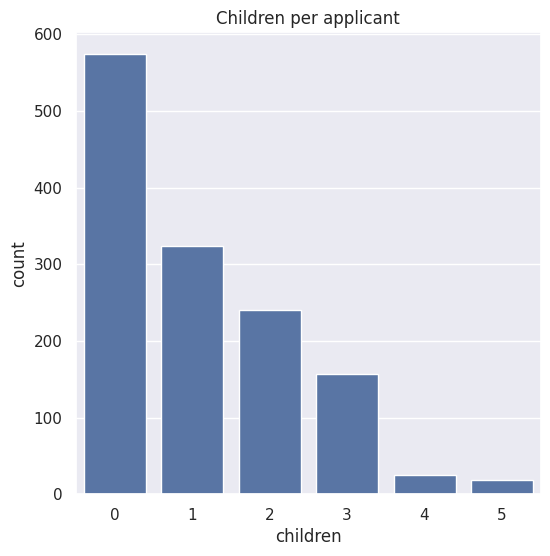

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [11]:
# Distribution of the number of children for applicants 
plt.figure(figsize=(6,6))
sns.countplot(x = 'children', data= data_set)
plt.title("Children per applicant")
plt.show()
data_set['children'].value_counts()

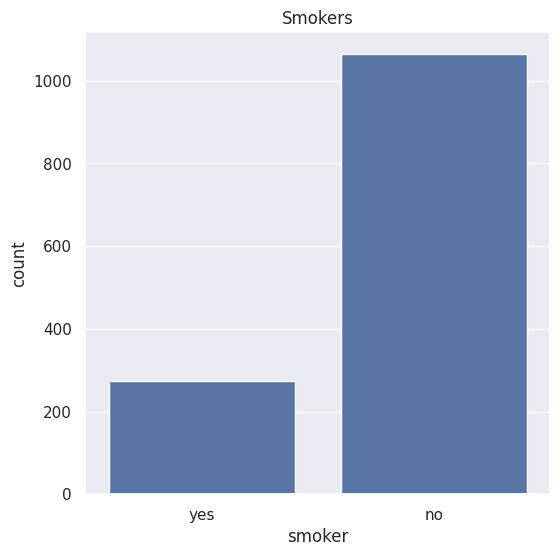

smoker
no     1064
yes     274
Name: count, dtype: int64

In [12]:
# Number of smokers of applicants
plt.figure(figsize=(6,6))
sns.countplot(x = 'smoker', data= data_set)
plt.title("Smokers")
plt.show()
data_set['smoker'].value_counts()

In [13]:
# Date pre-processing 
# The machine cannot categorical values to numerical via encoding

# Create encoder
le = LabelEncoder()

# Apply on categorical column
data_set['sex'] = le.fit_transform(data_set['sex'])
data_set['region'] = le.fit_transform(data_set['region'])
data_set['smoker'] = le.fit_transform(data_set['smoker'])

In [14]:
# Splitting the data into features and target
x = data_set.drop(columns=['charges'])
y = data_set['charges']

In [15]:
# Spliting the data into training and testing data using train_test_split method

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 123)
print(x.shape, x_train.shape, x_test.shape)
print(y.shape, y_train.shape, y_test.shape)


(1338, 6) (1070, 6) (268, 6)
(1338,) (1070,) (268,)


In [16]:
# getting the model and training the model using .fit()
model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [17]:
# Predicting on the training data
training_prediction = model.predict(x_train)

# Predicting on the testing data
testing_prediction = model.predict(x_test)


In [18]:
# Evaluating the model prediction using the r2_score from metircs

# accuracy score of the training 
r2_train = metrics.r2_score(y_train, training_prediction)

# accuracy score of the training 
r2_test = metrics.r2_score(y_test, testing_prediction)

print("The r2_score of the training prediction is ", r2_train * 100)
print("The r2_score of the testing prediction is ", r2_test * 100)

The r2_score of the training prediction is  73.74832271482907
The r2_score of the testing prediction is  79.9859199880231


**Building an predictive system**

In [19]:
input_data = {
    'age': [31],
    'sex': [1],          # male = 1, female = 0
    'bmi': [25.74],
    'children': [0],
    'smoker': [0],       # no = 0, yes = 1
    'region': [2]        # encoded region value
}

input_df = pd.DataFrame(input_data)

# Prediction
prediction = model.predict(input_df)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: 4046.5164112752645
